# Libraries and functions

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_err_vs_norm_all_curves(
    data,
    norm_type="spectral_complexity",
    y_plot="error",
    ax=None,
    figsize=(7, 5),
    lw=1.5,
    alpha=0.9,
    use_log_color=True,
    xscale="linear",
    yscale="linear",
    add_colorbar=True,
    title=None,
    average_seeds=False,
    avg_num_x=200,
    avg_min_count=1,
    return_avg_data=False,
):
    """
    Plot test error (or another observable) versus a chosen norm/time.

    Parameters
    ----------
    data : dict
        Loaded npy dictionary:
        data = np.load(path, allow_pickle=True).item()

    norm_type : str
        "spectral_complexity", "spectral_complexity_no_QK", "l2", "margin_std", or "time"

    y_plot : str
        "error", "spectral_complexity", "spectral_complexity_no_QK", "l2", or "margin_std"

    average_seeds : bool
        If False, plot all seed curves.
        If True, average curves across seeds for each P after interpolation on a
        single global log-spaced x-grid.

    avg_num_x : int
        Number of points in the common x-grid used for averaging.

    avg_min_count : int
        Minimum number of non-NaN seed contributions required at a grid point
        to plot the averaged curve there.

    return_avg_data : bool
        If True, also return a dictionary containing the common grid and the
        averaged/interpolated curves.

    Returns
    -------
    fig, ax
        If return_avg_data is True, also returns avg_data.
    """

    def _get_y_array(data, y_plot):
        if y_plot == "error":
            return np.asarray(data["err_seeds"]), "test error"
        elif y_plot == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm"
        elif y_plot == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm"
        elif y_plot == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm"
        elif y_plot == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale"
        elif y_plot == "margin_mean":
            return np.asarray(data["margin_mean_seeds"]), "Margin mean"
        elif y_plot == "margin_min":
            return np.asarray(data["margin_min_seeds"]), "Margin min"
        elif y_plot == "margin_max":
            return np.asarray(data["margin_max_seeds"]), "Margin max"
        else:
            raise ValueError(
                "y_plot must be one of: "
                "'error', 'spectral_complexity', 'spectral_complexity_no_QK', 'l2', 'margin_std'"
            )

    def _get_x_array(data, norm_type, err_shape, P_values):
        if norm_type == "spectral_complexity":
            return np.asarray(data["spectral_seeds"]), "spectral complexity norm"
        elif norm_type == "spectral_complexity_no_QK":
            return np.asarray(data["spectral_no_qk_seeds"]), "spectral complexity norm"
        elif norm_type == "l2":
            return np.asarray(data["l2_seeds"]), "L2 norm"
        elif norm_type == "margin_std":
            return np.asarray(data["margin_std_seeds"]), "Margin scale"
        elif norm_type == "time":
            t_arr = np.asarray(data["T_arr"])
            x = np.broadcast_to(
                t_arr[None, :, None],
                (err_shape[0], err_shape[1], err_shape[2])
            ).astype(float)
            for iP, P in enumerate(P_values):
                x[iP, :, :] = x[iP, :, :]  / (128.0 / P)
            return x, "t"
        else:
            raise ValueError(
                "norm_type must be one of: "
                "'spectral_complexity', 'spectral_complexity_no_QK', 'l2', 'margin_std', 'time'"
            )

    def _valid_curve(x, y, xscale, yscale, drop_first_n=2):
        x = np.asarray(x, dtype=float)[drop_first_n:]
        y = np.asarray(y, dtype=float)[drop_first_n:]

        mask = np.isfinite(x) & np.isfinite(y)
        if xscale == "log":
            mask &= (x > 0)
        if yscale == "log":
            mask &= (y > 0)

        x = x[mask]
        y = y[mask]

        if x.size < 2:
            return None, None

        # sort by x
        order = np.argsort(x)
        x = x[order]
        y = y[order]

        # remove repeated x values (keep first occurrence)
        x_unique, unique_idx = np.unique(x, return_index=True)
        y_unique = y[unique_idx]

        if x_unique.size < 2:
            return None, None

        return x_unique, y_unique

    def _interp_on_log_grid(x, y, x_grid):
        # interpolate y(x) using log10(x)
        return np.interp(
            np.log10(x_grid),
            np.log10(x),
            y,
            left=np.nan,
            right=np.nan,
        )

    P_values = np.asarray(data["P_values"])
    num_seeds = np.asarray(data["num_seeds"])

    err_seeds, ylabel = _get_y_array(data, y_plot)
    norm_seeds, xlabel = _get_x_array(data, norm_type, err_seeds.shape, P_values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    cmap = mpl.cm.get_cmap("viridis")

    if len(P_values) == 1:
        def color_of_P(P):
            return cmap(1.0)
        sm = None
    else:
        if use_log_color:
            color_norm = mpl.colors.LogNorm(
                vmin=np.min(P_values),
                vmax=np.max(P_values) + 10000
            )
        else:
            color_norm = mpl.colors.Normalize(
                vmin=np.min(P_values),
                vmax=np.max(P_values)
            )

        def color_of_P(P):
            return cmap(color_norm(P))

        sm = mpl.cm.ScalarMappable(norm=color_norm, cmap=cmap)
        sm.set_array([])

    nP, nT, nS = err_seeds.shape

    avg_data = {
        "P_values": P_values.copy(),
        "x_grid": None,
        "mean_curves": None,
        "counts": None,
        "interpolated_curves": None,
    }

    if not average_seeds:
        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)

            for iseed in range(num_seeds[iP]):
                #if iseed == 2:
                x = norm_seeds[iP, :, iseed]
                y = err_seeds[iP, :, iseed]
                x, y = _valid_curve(x, y, xscale, yscale, drop_first_n=2)
                if x is None:
                    continue
                ax.plot(
                    x,
                    y,
                    color=this_color,
                    lw=lw,
                    alpha=alpha,
                )

    else:
        # ---------------------------------------------------------
        # 1) build one global log-spaced x-grid from ALL valid curves
        # ---------------------------------------------------------
        global_x_min = np.inf
        global_x_max = -np.inf

        for iP in range(nP):
            for iseed in range(num_seeds[iP]):
                x = norm_seeds[iP, :, iseed]
                y = err_seeds[iP, :, iseed]

                # for averaging on a log-grid, x must be positive
                x_valid, y_valid = _valid_curve(x, y, "log", yscale, drop_first_n=2)
                if x_valid is None:
                    continue

                global_x_min = min(global_x_min, np.min(x_valid))
                global_x_max = max(global_x_max, np.max(x_valid))

        if not np.isfinite(global_x_min) or not np.isfinite(global_x_max):
            raise ValueError("No valid positive x values found to build the common log-spaced grid.")

        if global_x_min <= 0:
            raise ValueError("Global x-grid for averaging requires strictly positive x values.")

        x_grid = np.logspace(np.log10(global_x_min), np.log10(global_x_max), avg_num_x)

        mean_curves = np.full((nP, avg_num_x), np.nan, dtype=float)
        counts = np.zeros((nP, avg_num_x), dtype=int)
        interpolated_curves = np.full((nP, nS, avg_num_x), np.nan, dtype=float)

        # ---------------------------------------------------------
        # 2) interpolate each seed curve on that common grid
        # 3) average across seeds for each P
        # ---------------------------------------------------------
        for iP in range(nP):
            P = P_values[iP]
            this_color = color_of_P(P)

            interp_list = []

            for iseed in range(num_seeds[iP]):
                x = norm_seeds[iP, :, iseed]
                y = err_seeds[iP, :, iseed]

                x_valid, y_valid = _valid_curve(x, y, "log", yscale, drop_first_n=2)
                if x_valid is None:
                    continue

                y_interp = _interp_on_log_grid(x_valid, y_valid, x_grid)
                interp_list.append(y_interp)
                interpolated_curves[iP, iseed, :] = y_interp

            if len(interp_list) == 0:
                continue

            interp_arr = np.asarray(interp_list)  # shape (n_valid_seeds, avg_num_x)
            mean_curve = np.nanmean(interp_arr, axis=0)
            count_curve = np.sum(np.isfinite(interp_arr), axis=0)

            # require a minimum number of contributing seeds
            mean_curve[count_curve < avg_min_count] = np.nan

            mean_curves[iP, :] = mean_curve
            counts[iP, :] = count_curve

            mask_plot = np.isfinite(mean_curve)
            if np.any(mask_plot):
                ax.plot(
                    x_grid[mask_plot],
                    mean_curve[mask_plot],
                    color=this_color,
                    lw=lw,
                    alpha=alpha,
                )

        avg_data["x_grid"] = x_grid
        avg_data["mean_curves"] = mean_curves
        avg_data["counts"] = counts
        avg_data["interpolated_curves"] = interpolated_curves

    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and sm is not None:
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("P")

    plt.tight_layout()

    if return_avg_data:
        return fig, ax, avg_data
    return fig, ax

In [2]:
res = np.load("results/exp_base_v5.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152]
epochs: [ 0  1  2  3  5  6  7 10 20 25 30 40 50 60 64]
num seeds: [3 3 3 3 3 3 3 3]
fixed params: {'dataset': 'rhm', 'mode': 'masked', 'num_features': 32, 'num_classes': 32, 'num_synonyms': 8, 'tuple_size': 2, 'num_layers': 3, 'path': None, 'num_tokens': 8, 'batch_size': 128, 'test_size': 32768, 'input_form

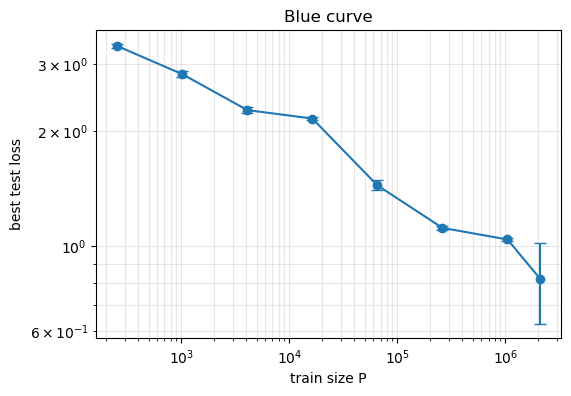

In [4]:
P = res["P_values"]
y = res["best_loss_mean"]
yerr = np.where(res["best_loss_std"] < 0, 0.0, res["best_loss_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("train size P")
plt.ylabel("best test loss")
plt.title("Blue curve")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Norm study, RHM power law

## Init scale 0.8, a=2

In [24]:
res = np.load("results/exp_A2_v1.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'margin_min_raw', 'margin_mean_raw', 'margin_max_raw', 'margin_std_raw', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_raw', 'spectral_no_qk_seeds', 'l2_seeds', 'margin_min_seeds', 'margin_mean_seeds', 'margin_max_seeds', 'margin_std_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'margin_min_mean', 'margin_min_std', 'margin_min_n', 'margin_mean_mean', 'margin_mean_std', 'margin_mean_n', 'margin_max_mean', 'margin_max_std', 'margin_max_n', 'margin_std_mean', 'margin_std_std', 'margin_std_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'la

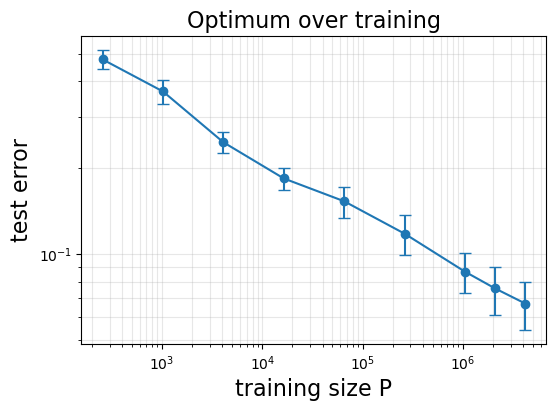

In [25]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_14361/3953630492.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_14361/3953630492.py:271: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

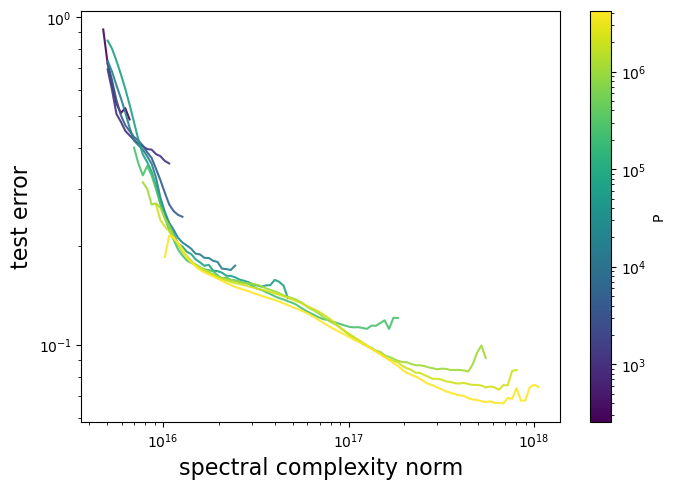

In [26]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",   
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_14361/3953630492.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_14361/3953630492.py:271: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

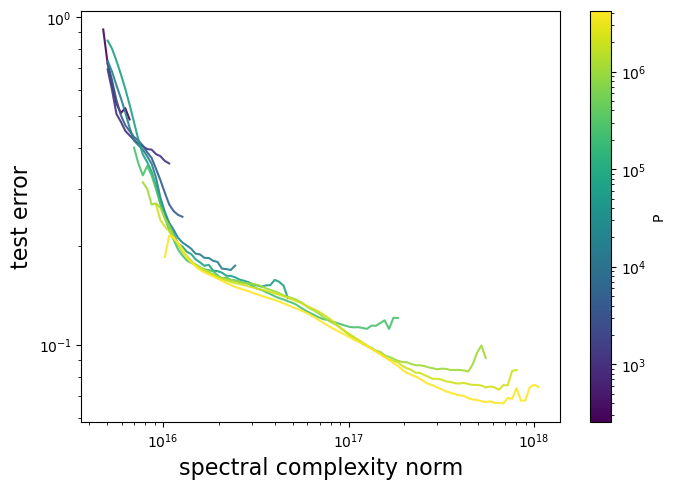

In [27]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,

)


/tmp/ipykernel_14361/3052900188.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_14361/3052900188.py:271: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

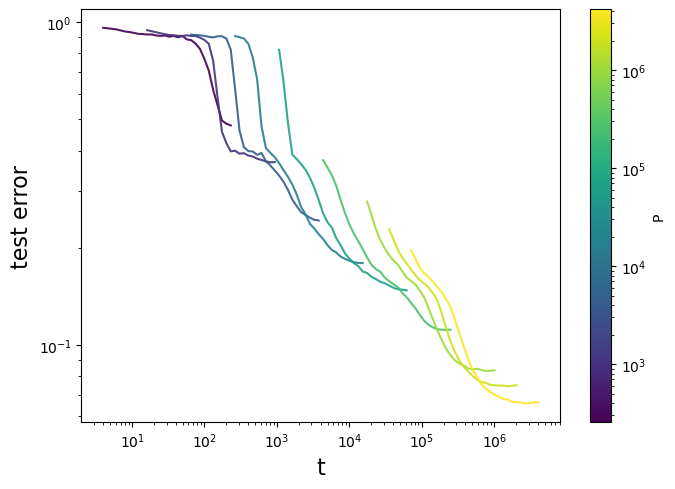

In [30]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,

)


/tmp/ipykernel_10577/2091998185.py:153: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_10577/2091998185.py:266: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='L2 norm', ylabel='test error'>)

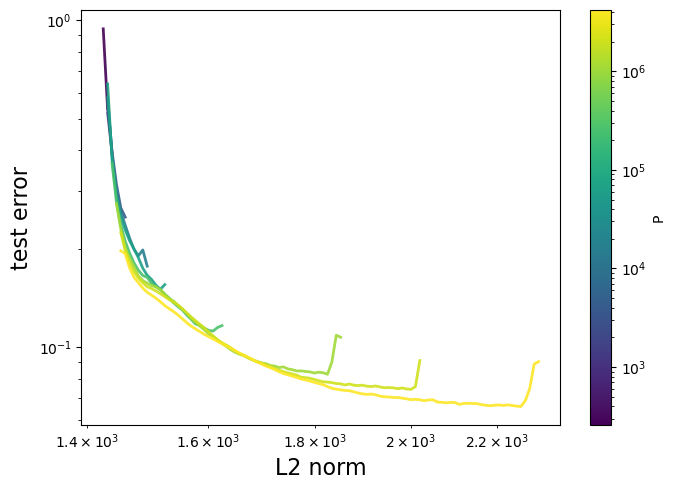

In [33]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="l2",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,

)


/tmp/ipykernel_10577/2091998185.py:153: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_10577/2091998185.py:266: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='L2 norm', ylabel='spectral complexity norm'>)

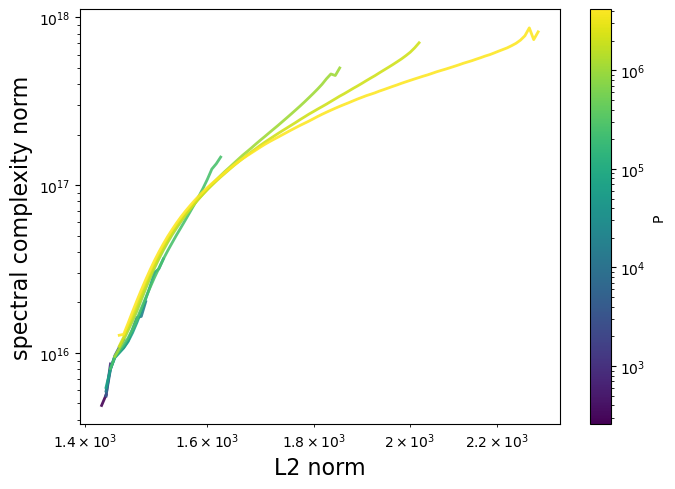

In [41]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity_no_QK",
    norm_type="l2",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,

)


# Norm study, RHM uniform

## Init scale = 0.8

### No Q,K

In [2]:
res = np.load("results/exp_base_v13.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_raw', 'spectral_no_qk_seeds', 'l2_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152 4194304]
epochs: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47

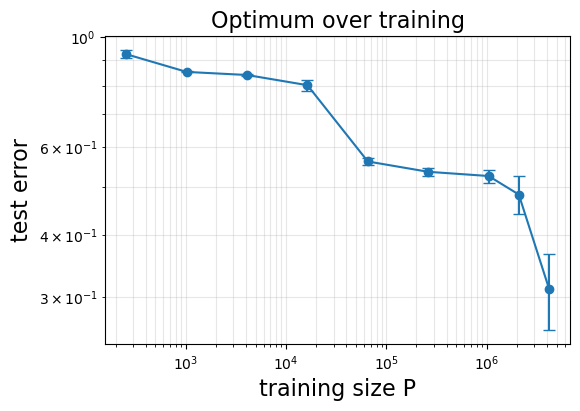

In [16]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_5502/1868873205.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")
/tmp/ipykernel_5502/1868873205.py:272: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(interp_arr, axis=0)


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

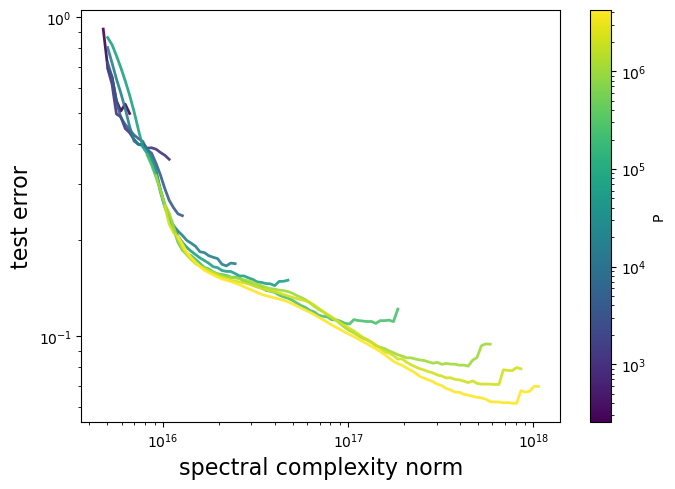

In [33]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=100,
)


/tmp/ipykernel_13394/2478624447.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

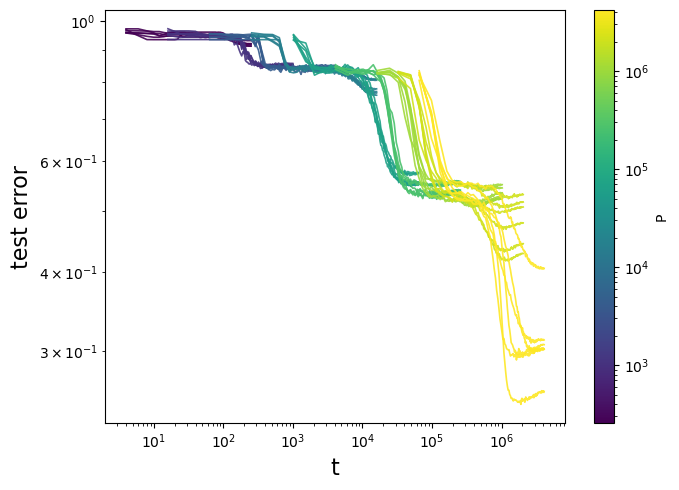

In [11]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_13394/4108429274.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

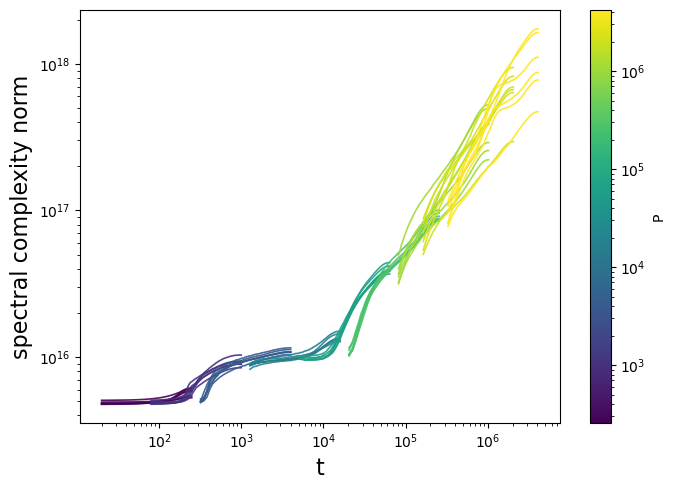

In [8]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity_no_QK",
    norm_type="time",
    xscale="log",
    yscale="log",
)


### With Q,K

In [18]:
res = np.load("results/exp_base_v12.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_raw', 'spectral_no_qk_seeds', 'l2_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152 4194304]
epochs: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47

In [ ]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

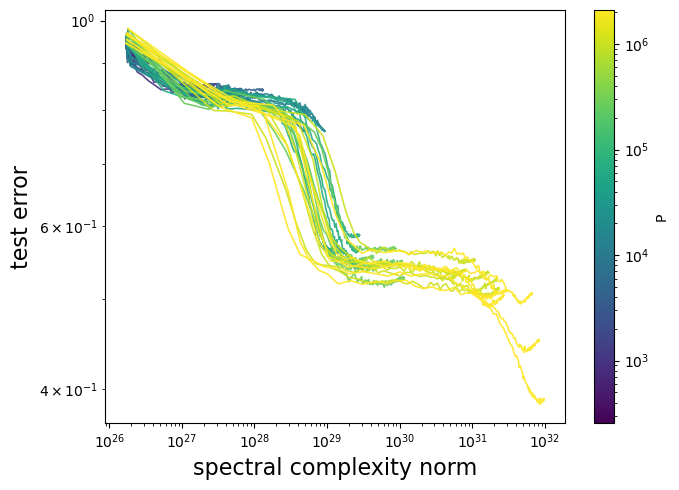

In [39]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='L2 norm', ylabel='test error'>)

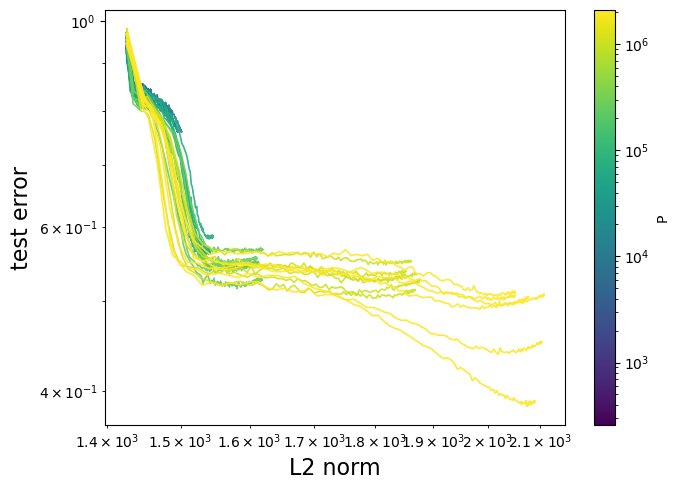

In [40]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="l2",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

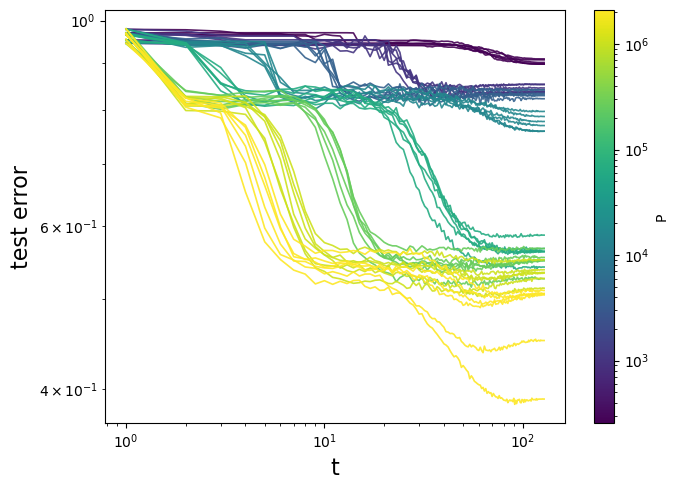

In [41]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

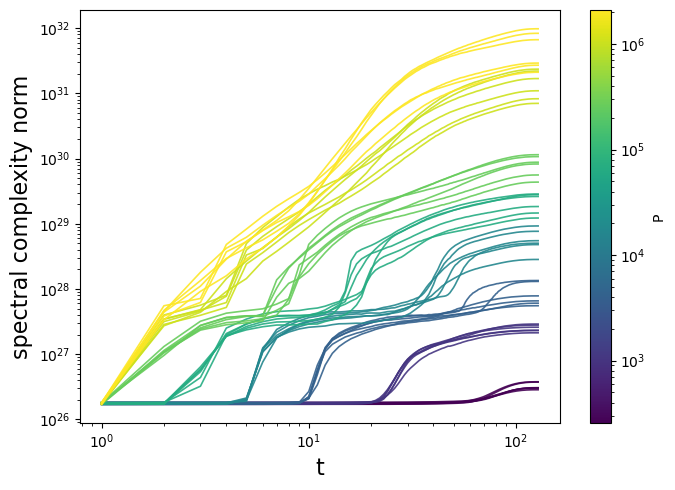

In [42]:


plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity",
    norm_type="time",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/1450215154.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='L2 norm'>)

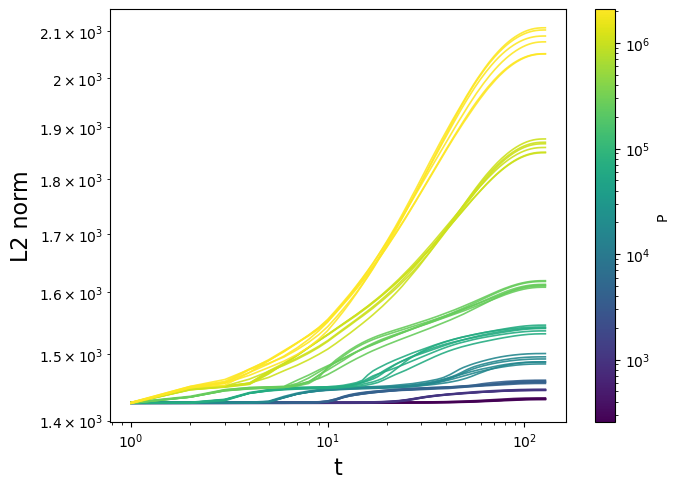

In [44]:


plot_err_vs_norm_all_curves(
    res,
    y_plot = "l2",
    norm_type="time",
    xscale="log",
    yscale="log",
)


# Same dataset

In [6]:
res = np.load("results/exp_A2_FULL_v2.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'margin_min_raw', 'margin_mean_raw', 'margin_max_raw', 'margin_std_raw', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_raw', 'spectral_no_qk_seeds', 'l2_seeds', 'margin_min_seeds', 'margin_mean_seeds', 'margin_max_seeds', 'margin_std_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'margin_min_mean', 'margin_min_std', 'margin_min_n', 'margin_mean_mean', 'margin_mean_std', 'margin_mean_n', 'margin_max_mean', 'margin_max_std', 'margin_max_n', 'margin_std_mean', 'margin_std_std', 'margin_std_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'la

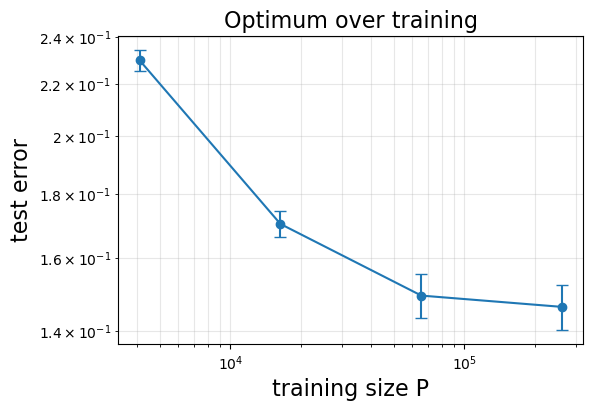

In [7]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_14361/265636631.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

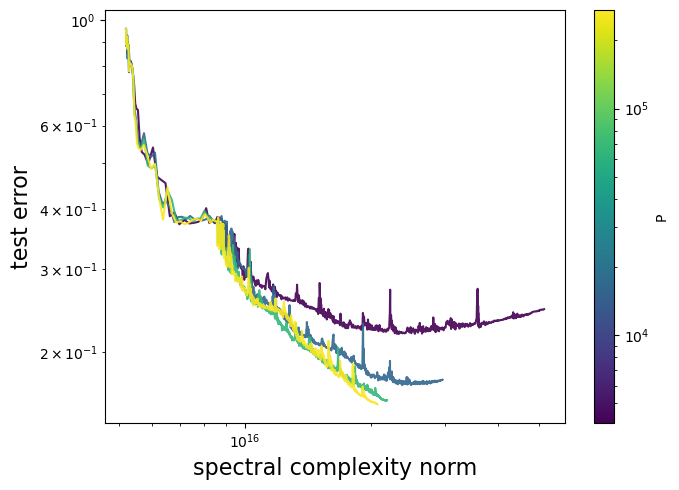

In [18]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "error",
    norm_type= "spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
)

/tmp/ipykernel_14361/2636883788.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

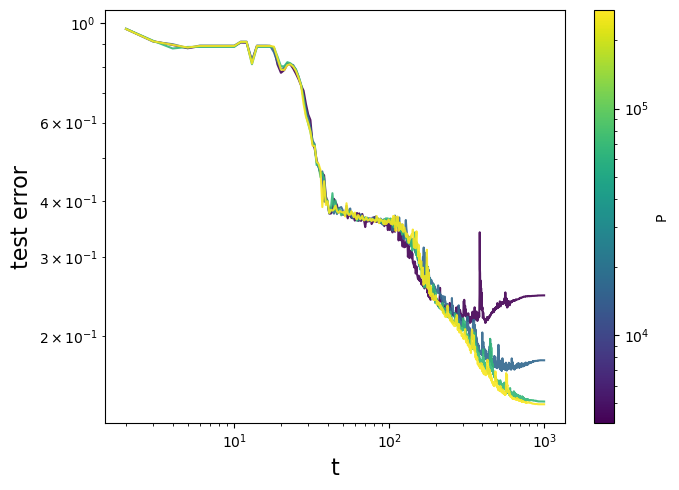

In [16]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "error",
    norm_type= "time",
    xscale="log",
    yscale="log",

)

/tmp/ipykernel_14361/265636631.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

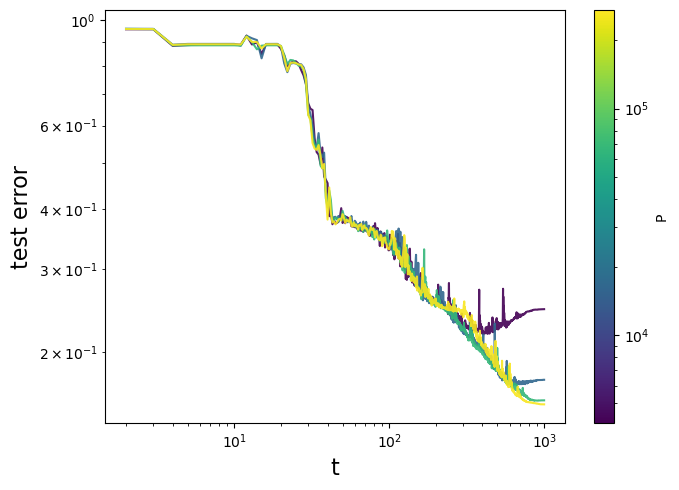

In [ ]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "error",
    norm_type= "time",
    xscale="log",
    yscale="log",
)

/tmp/ipykernel_14361/3145646377.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

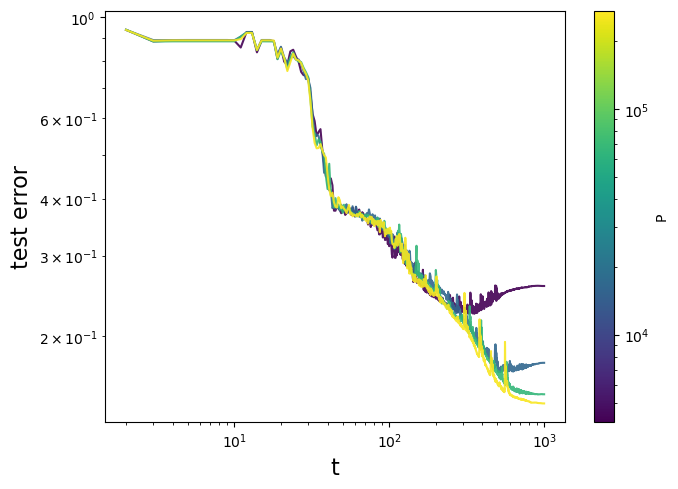

In [21]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "error",
    norm_type= "time",
    xscale="log",
    yscale="log",
)

/tmp/ipykernel_14361/3145646377.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

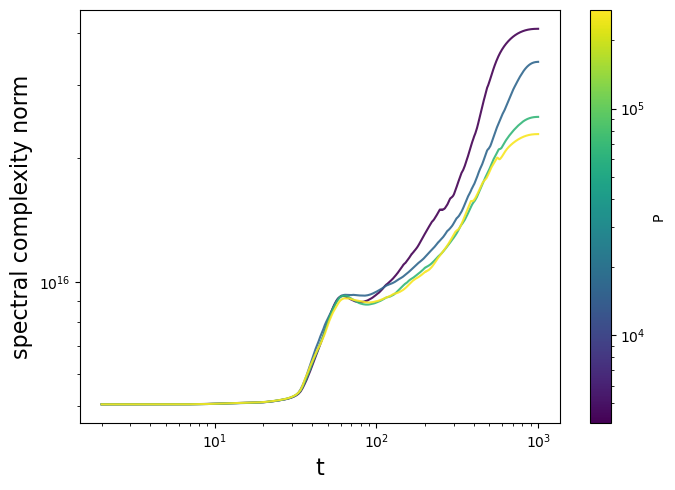

In [22]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity_no_QK",
    norm_type= "time",
    xscale="log",
    yscale="log",

)

/tmp/ipykernel_31834/858810506.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='Margin scale'>)

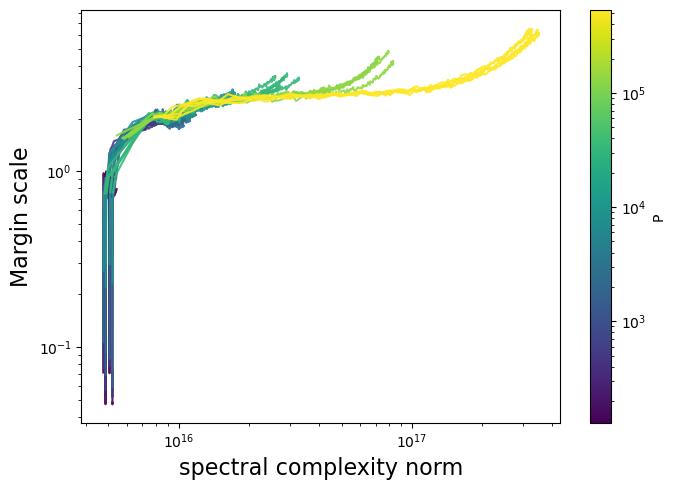

In [11]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "margin_std",
    norm_type= "spectral_complexity_no_QK",
    xscale="log",
    yscale="log",

)